In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('indicadores_educacionais_uf_2013.csv')

df.head()

,ano,sigla_uf,localizacao,rede,atu_ei,atu_ei_creche,atu_ei_pre_escola,atu_ef,atu_ef_anos_iniciais,atu_ef_anos_finais,...,ied_em_nivel_3,ied_em_nivel_4,ied_em_nivel_5,ied_em_nivel_6,icg_nivel_1,icg_nivel_2,icg_nivel_3,icg_nivel_4,icg_nivel_5,icg_nivel_6
0,2013,GO,total,estadual,14.9,NaN,14.9,26.9,22.6,28.0,...,24.4,48.5,15.2,5.2,8.2,6.3,21.3,45.6,16.2,2.4
1,2013,GO,urbana,estadual,17.9,NaN,17.9,27.4,23.0,28.6,...,24.6,48.3,15.3,5.3,7.8,6.3,19.6,46.5,17.2,2.6
2,2013,PB,rural,estadual,15.1,17.0,14.7,17.1,15.6,20.4,...,18.1,38.2,20.5,9.8,13.6,8.8,35.2,21.6,18.4,2.4
3,2013,RJ,rural,estadual,NaN,NaN,NaN,23.6,20.2,24.1,...,12.2,44.2,21.7,16.8,9.2,7.1,22.4,36.7,23.5,1.1
4,2013,DF,rural,federal,NaN,NaN,NaN,NaN,NaN,NaN,...,34.3,40.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0


##### Seleção das colunas de interesse

In [3]:
colunas_desejadas = ['sigla_uf','localizacao','rede','taxa_aprovacao_ef', 'taxa_aprovacao_em', 'taxa_reprovacao_ef',
                     'taxa_reprovacao_em', 'taxa_abandono_ef', 'taxa_abandono_em']

df = df.loc[df['localizacao'] == 'urbana']

df = df.loc[df['rede'] == 'estadual']

df.loc[:, colunas_desejadas]

,sigla_uf,localizacao,rede,taxa_aprovacao_ef,taxa_aprovacao_em,taxa_reprovacao_ef,taxa_reprovacao_em,taxa_abandono_ef,taxa_abandono_em
1,GO,urbana,estadual,91.7,83.7,5.7,9.1,2.6,7.2
71,PR,urbana,estadual,82.8,78.2,14.0,14.3,3.2,7.5
76,MT,urbana,estadual,98.1,60.6,1.2,24.2,0.7,15.2
97,PA,urbana,estadual,74.5,67.6,19.1,13.9,6.4,18.5
100,PE,urbana,estadual,81.9,83.9,14.7,10.9,3.4,5.2
108,PB,urbana,estadual,77.7,74.9,14.0,9.8,8.3,15.3
114,RO,urbana,estadual,84.3,77.0,12.8,11.1,2.9,11.9
125,PI,urbana,estadual,79.0,74.9,16.3,9.7,4.7,15.4
134,DF,urbana,estadual,86.5,73.9,12.0,18.6,1.5,7.5
156,CE,urbana,estadual,83.9,83.2,10.5,7.2,5.6,9.6


In [4]:
uf_para_regiao = {
    "AC": "Norte",
    "AL": "Nordeste",
    "AM": "Norte",
    "AP": "Norte",
    "BA": "Nordeste",
    "CE": "Nordeste",
    "DF": "Centro-Oeste",
    "ES": "Sudeste",
    "GO": "Centro-Oeste",
    "MA": "Nordeste",
    "MG": "Sudeste",
    "MS": "Centro-Oeste",
    "MT": "Centro-Oeste",
    "PA": "Norte",
    "PB": "Nordeste",
    "PE": "Nordeste",
    "PI": "Nordeste",
    "PR": "Sul",
    "RJ": "Sudeste",
    "RN": "Nordeste",
    "RO": "Norte",
    "RR": "Norte",
    "RS": "Sul",
    "SC": "Sul",
    "SE": "Nordeste",
    "SP": "Sudeste",
    "TO": "Norte"
}


df["regiao"] = df["sigla_uf"].map(uf_para_regiao)



##### Gráfico com as taxas de aprovação no Ensino Fundamental separadas por região

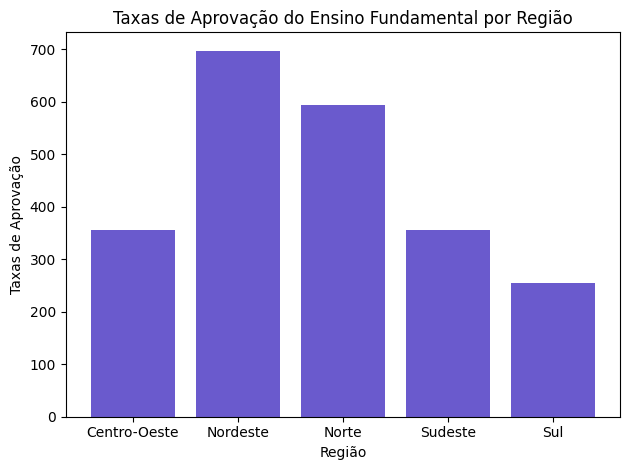

In [7]:
# Calcular a soma das taxas de aprovação no ensino fundamental por região
soma_taxas_regiao_ap_ef = df.groupby("regiao")["taxa_aprovacao_ef"].sum()

# Plotar o gráfico de barras
plt.bar(soma_taxas_regiao_ap_ef.index, soma_taxas_regiao_ap_ef.values, color='#6A5ACD')
plt.xlabel("Região")
plt.ylabel("Taxas de Aprovação")
plt.title("Taxas de Aprovação do Ensino Fundamental por Região")
plt.tight_layout()

plt.show()

##### Gráfico com as taxas de reprovação no Ensino Fundamental separadas por região

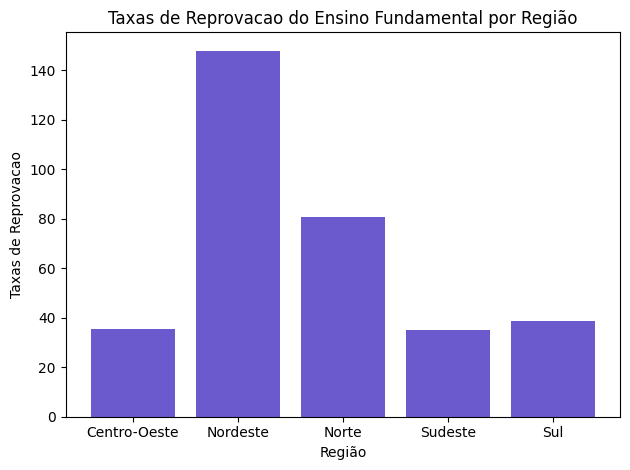

In [8]:
# Calcular a soma das taxas de reprovação no ensino fundamental por região
soma_taxas_regiao_rep_ef = df.groupby("regiao")["taxa_reprovacao_ef"].sum()

# Plotar o gráfico de barras
plt.bar(soma_taxas_regiao_rep_ef.index, soma_taxas_regiao_rep_ef.values, color='#6A5ACD')
plt.xlabel("Região")
plt.ylabel("Taxas de Reprovacao")
plt.title("Taxas de Reprovacao do Ensino Fundamental por Região")
plt.tight_layout()

plt.show()


##### Gráfico com as taxas de abandono no Ensino Fundamental separadas por região

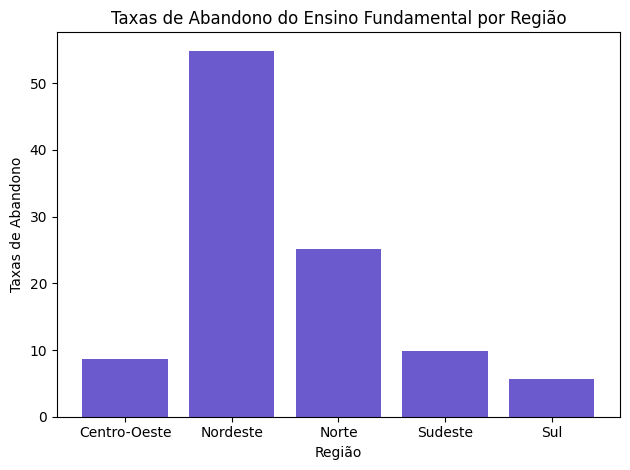

In [9]:
# Calcular a soma das taxas de abandono no ensino fundamental por região
soma_taxas_regiao_ab_ef = df.groupby("regiao")["taxa_abandono_ef"].sum()

# Plotar o gráfico de barras
plt.bar(soma_taxas_regiao_ab_ef.index, soma_taxas_regiao_ab_ef.values, color='#6A5ACD')
plt.xlabel("Região")
plt.ylabel("Taxas de Abandono")
plt.title("Taxas de Abandono do Ensino Fundamental por Região")
plt.tight_layout()

plt.show()


#### Gráfico de barras agrupadas para melhor visualização e comparação dos dados referentes ao Ensino Fundamental

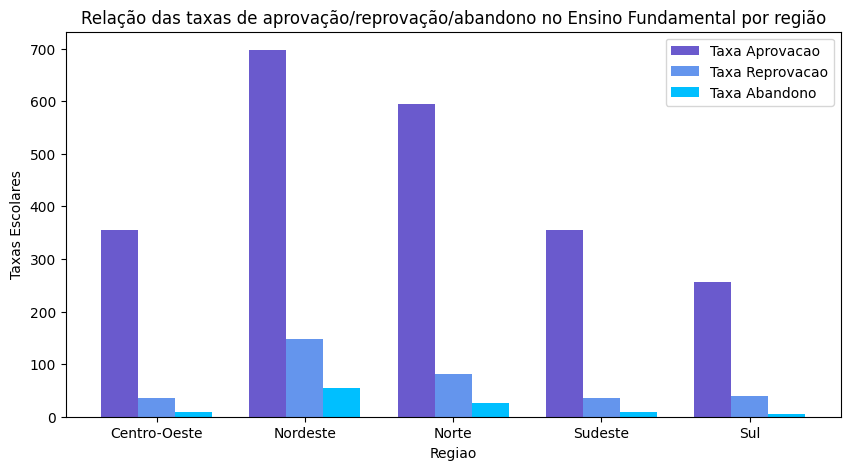

In [10]:
# Definindo a largura das barras
larguraBarra = 0.25

# Aumentando a posição das barras
plt.figure(figsize=(10,5))

# Definindo a posição das barras
r1 = np.arange(len(soma_taxas_regiao_ap_ef))
r2 = [x + larguraBarra for x in r1]
r3 = [x + larguraBarra for x in r2]

# Criando as barras
plt.bar(r1, soma_taxas_regiao_ap_ef, color='#6A5ACD', width = larguraBarra, label='Taxa Aprovacao')
plt.bar(r2, soma_taxas_regiao_rep_ef, color='#6495ED', width = larguraBarra, label='Taxa Reprovacao')
plt.bar(r3, soma_taxas_regiao_ab_ef, color='#00BFFF', width = larguraBarra, label='Taxa Abandono')

# Legendas das barras
plt.xlabel('Regiao')
plt.xticks([r + larguraBarra for r in range(len(soma_taxas_regiao_ap_ef))], soma_taxas_regiao_ap_ef.index)
plt.ylabel('Taxas Escolares')
plt.title('Relação das taxas de aprovação/reprovação/abandono no Ensino Fundamental por região')

plt.legend()
plt.show()

##### Gráfico com as taxas de aprovação no Ensino Médio separadas por região

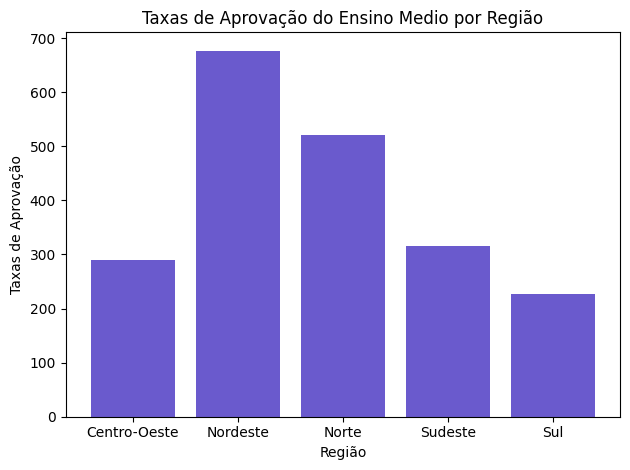

In [11]:
# Calcular a soma das taxas de aprovação no ensino médio por região
soma_taxas_regiao_ap_em = df.groupby("regiao")["taxa_aprovacao_em"].sum()

# Plotar o gráfico de barras
plt.bar(soma_taxas_regiao_ap_em.index, soma_taxas_regiao_ap_em.values, color='#6A5ACD')
plt.xlabel("Região")
plt.ylabel("Taxas de Aprovação")
plt.title("Taxas de Aprovação do Ensino Medio por Região")
plt.tight_layout()

plt.show()

##### Gráfico com as taxas de reprovação no Ensino Médio separadas por região

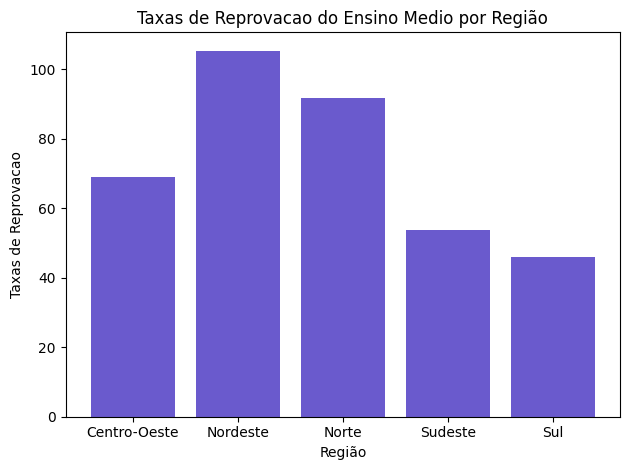

In [12]:
# Calcular a soma das taxas de reprovação no ensino médio por região
soma_taxas_regiao_rep_em = df.groupby("regiao")["taxa_reprovacao_em"].sum()

# Plotar o gráfico de barras
plt.bar(soma_taxas_regiao_rep_em.index, soma_taxas_regiao_rep_em.values, color='#6A5ACD')
plt.xlabel("Região")
plt.ylabel("Taxas de Reprovacao")
plt.title("Taxas de Reprovacao do Ensino Medio por Região")
plt.tight_layout()

plt.show()

##### Gráfico com as taxas de abandono no Ensino Médio separadas por região

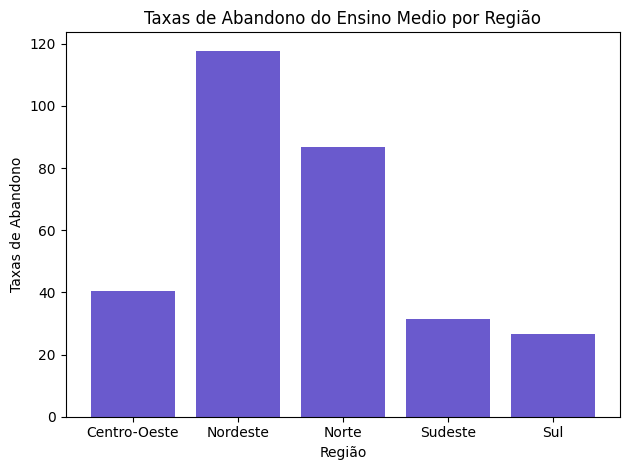

In [13]:
# Calcular a soma das taxas de abandono no ensino médio por região
soma_taxas_regiao_ab_em = df.groupby("regiao")["taxa_abandono_em"].sum()

# Plotar o gráfico de barras
plt.bar(soma_taxas_regiao_ab_em.index, soma_taxas_regiao_ab_em.values, color='#6A5ACD')
plt.xlabel("Região")
plt.ylabel("Taxas de Abandono")
plt.title("Taxas de Abandono do Ensino Medio por Região")
plt.tight_layout()

plt.show()

#### Gráfico de barras agrupadas para melhor visualização e comparação dos dados referentes ao Ensino Médio

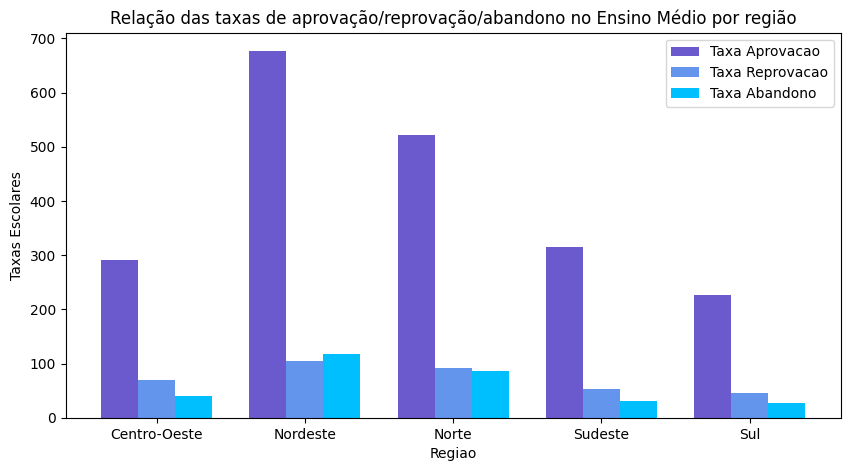

In [14]:
# Definindo a largura das barras
larguraBarra = 0.25

# Aumentando a posição das barras
plt.figure(figsize=(10,5))

# Definindo a posição das barras
r1 = np.arange(len(soma_taxas_regiao_ap_em))
r2 = [x + larguraBarra for x in r1]
r3 = [x + larguraBarra for x in r2]

# Criando as barras
plt.bar(r1, soma_taxas_regiao_ap_em, color='#6A5ACD', width = larguraBarra, label='Taxa Aprovacao')
plt.bar(r2, soma_taxas_regiao_rep_em, color='#6495ED', width = larguraBarra, label='Taxa Reprovacao')
plt.bar(r3, soma_taxas_regiao_ab_em, color='#00BFFF', width = larguraBarra, label='Taxa Abandono')

# Legendas das barras
plt.xlabel('Regiao')
plt.xticks([r + larguraBarra for r in range(len(soma_taxas_regiao_ap_em))], soma_taxas_regiao_ap_em.index)
plt.ylabel('Taxas Escolares')
plt.title('Relação das taxas de aprovação/reprovação/abandono no Ensino Médio por região')

plt.legend()
plt.show()

### Investimento - 2013

In [15]:
df_investimento = pd.read_csv('atlas_esgotos_municipio.csv')

df_investimento.head()

,id_municipio,sigla_uf,populacao_urbana_2013,populacao_urbana_2035,prestador_servico_esgotamento_sanitario,sigla_prestador,indice_sem_atendimento_sem_coleta_sem_tratamento,indice_atendimento_solucao_individual,indice_atendimento_com_coleta_sem_tratamento,indice_atendimento_com_coleta_com_tratamento,...,carga_afluente_solucao_individual_2035,carga_efluente_solucao_individual_2035,populacao_atendida_2035,investimento_coleta,investimento_tratamento,investimento_coleta_tratatamento,necessidade_remocao_dbo,tipologia_solucao,atencao_fosforo,atencao_nitrogenio
0,1100015,RO,14735,15507,Serviço Autônomo de Água e Esgoto,SAAE,0.9673,0.0185,0.0142,0.00,...,83.7,33.5,13956,1.686679e+07,4.298530e+06,2.116532e+07,Acima de 80%,Tratamento secundário avançado,Não,Não
1,1100023,RO,85770,121503,Companhia de Águas e Esgotos de Rondônia,CAERD,0.8941,0.0858,0.0202,0.00,...,656.1,262.4,109353,1.194605e+08,2.504174e+07,1.445022e+08,Entre 60 e 80%,Tratamento secundário convencional,Não,Não
2,1100031,RO,2771,3349,Prefeitura Municipal de Cabixi,PM,0.9900,0.0063,0.0037,0.00,...,18.1,7.2,3014,4.860356e+06,6.902558e+05,5.550611e+06,Entre 60 e 80%,Tratamento secundário convencional,Não,Não
3,1100049,RO,67665,80311,Serviço Autônomo de Água e Esgoto de Cacoal,SAAE,0.2882,0.1618,0.0000,0.55,...,433.7,173.5,72280,3.892141e+07,4.891917e+06,4.381333e+07,Entre 60 e 80%,Tratamento secundário convencional,Não,Não
4,1100056,RO,15276,14254,Prefeitura Municipal de Cerejeiras,PM,0.7964,0.1969,0.0067,0.00,...,77.0,30.8,12829,1.562341e+07,3.951304e+06,1.957471e+07,Acima de 80%,Tratamento secundário avançado,Não,Não


###### Seleção das colunas de interesse

In [18]:
colunas_desejadas = ['id_municipio', 'sigla_uf', 'investimento_coleta',
                    'investimento_coleta_tratatamento', 'investimento_tratamento']

df_investimento = df_investimento.loc[:, colunas_desejadas]

df_investimento["regiao"] = df_investimento["sigla_uf"].map(uf_para_regiao)


##### Gráfico com as taxas de investimento em coleta de esgoto separadas por região

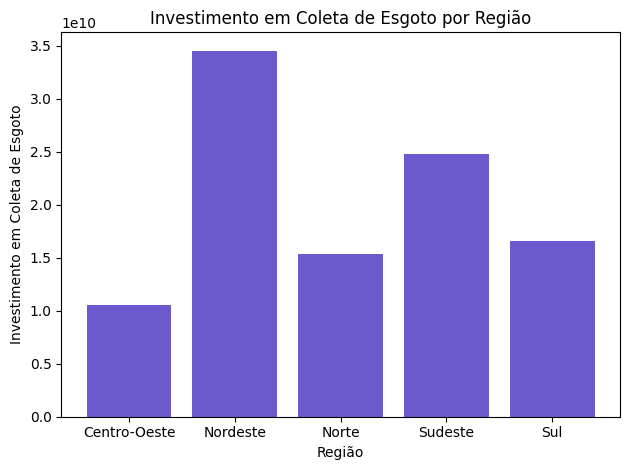

In [19]:
# Calcular a soma das taxas de investimento em coleta por região
soma_taxas_coleta_regiao = df_investimento.groupby("regiao")["investimento_coleta"].sum()

# Plotar o gráfico de barras
plt.bar(soma_taxas_coleta_regiao.index, soma_taxas_coleta_regiao.values, color='#6A5ACD')
plt.xlabel("Região")
plt.ylabel("Investimento em Coleta de Esgoto")
plt.title("Investimento em Coleta de Esgoto por Região")
plt.tight_layout()

plt.show()

##### Gráfico com as taxas de investimento em tratamento de esgoto separadas por região

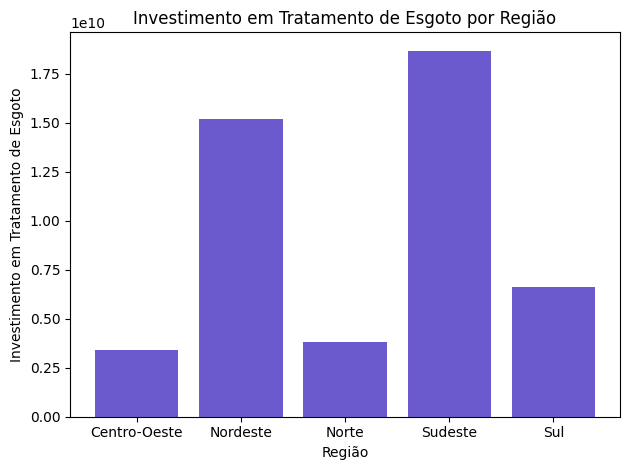

In [20]:
# Calcular a soma das taxas de investimento em tratamento de esgoto por região
soma_taxas_tratamento_regiao = df_investimento.groupby("regiao")["investimento_tratamento"].sum()

# Plotar o gráfico de barras
plt.bar(soma_taxas_tratamento_regiao.index, soma_taxas_tratamento_regiao.values, color='#6A5ACD')
plt.xlabel("Região")
plt.ylabel("Investimento em Tratamento de Esgoto")
plt.title("Investimento em Tratamento de Esgoto por Região")
plt.tight_layout()

plt.show()

##### Gráfico com as taxas de investimento em tratamento & coleta de esgoto separadas por região

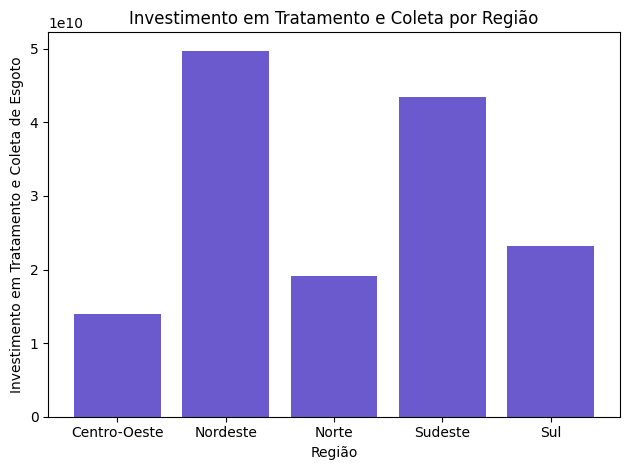

In [21]:
# Calcular a soma das taxas de investimento em tratamento & coleta de esgoto por região
soma_taxas__coleta_tratamento_regiao = df_investimento.groupby("regiao")["investimento_coleta_tratatamento"].sum()

# Plotar o gráfico de barras
plt.bar(soma_taxas__coleta_tratamento_regiao.index, soma_taxas__coleta_tratamento_regiao.values, color='#6A5ACD')
plt.xlabel("Região")
plt.ylabel("Investimento em Tratamento e Coleta de Esgoto")
plt.title("Investimento em Tratamento e Coleta por Região")
plt.tight_layout()

plt.show()